In [1]:
from tensorflow.keras.datasets import mnist

# Load and preprocess data
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0  # Normalize data

2024-08-30 18:11:30.655852: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-08-30 18:11:30.711719: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-08-30 18:11:30.724069: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-08-30 18:11:31.966659: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-08-30 18:12:05.805871: W tensorflow/compiler/tf2

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from PIL import Image

This is taking too long, we give up.

This is taking too long, we give up.

This is taking too long, we give up.

This is taking too long, we give up.

This is taking too long, we give up.

This is taking too long, we give up.

This is taking too long, we give up.



In [8]:
# Load MNIST dataset
(x_train, y_train), (_, _) = mnist.load_data()

# Choose an example image (e.g., the first image)
image = x_train[0]
label = y_train[0]


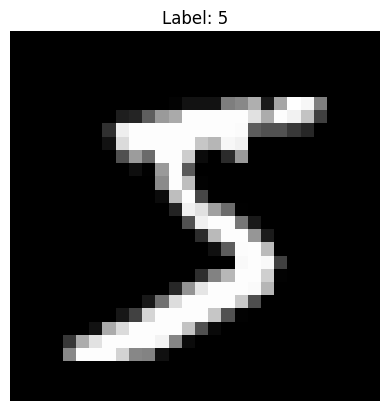

In [9]:

# Display the image using matplotlib
plt.imshow(image, cmap='gray')
plt.title(f'Label: {label}')
plt.axis('off')  # Hide axes
plt.show()

In [10]:


# Save the image as a PNG file
image = Image.fromarray(image)
image = image.convert('L')  # Ensure it's in grayscale mode
image.save( f"{label}.png")

print(f"Image saved as {label}.png")

Image saved as 5.png


In [11]:
import numpy as np
from tflite_runtime.interpreter import Interpreter
import json


In [12]:

model_path = 'digit_recognition.tflite'
interpreter = Interpreter(model_path=model_path)
interpreter.allocate_tensors()


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


In [13]:

# Get input and output tensors.
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()


In [26]:
input_details, output_details

([{'name': 'serving_default_keras_tensor:0',
   'index': 0,
   'shape': array([ 1, 28, 28], dtype=int32),
   'shape_signature': array([-1, 28, 28], dtype=int32),
   'dtype': numpy.float32,
   'quantization': (0.0, 0),
   'quantization_parameters': {'scales': array([], dtype=float32),
    'zero_points': array([], dtype=int32),
    'quantized_dimension': 0},
   'sparsity_parameters': {}}],
 [{'name': 'StatefulPartitionedCall_1:0',
   'index': 9,
   'shape': array([ 1, 10], dtype=int32),
   'shape_signature': array([-1, 10], dtype=int32),
   'dtype': numpy.float32,
   'quantization': (0.0, 0),
   'quantization_parameters': {'scales': array([], dtype=float32),
    'zero_points': array([], dtype=int32),
    'quantized_dimension': 0},
   'sparsity_parameters': {}}])

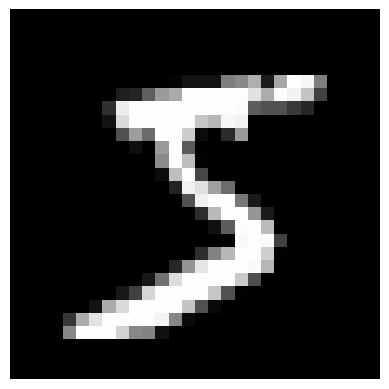

In [27]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Load the image
img = mpimg.imread('5.png')

# Display the image
plt.imshow(img, cmap='gray')
plt.axis('off')  # Hide axis labels
plt.show()

In [28]:

# Load and preprocess the image
def preprocess_image(image_path):
    # Load image
    img = Image.open(image_path).convert('L')  # Convert to grayscale
    img = img.resize((28, 28))  # Resize to 28x28 for MNIST
    img_array = np.array(img, dtype=np.float32)

    # Normalize the image
    img_array = img_array / 255.0

    # Add batch dimension
    img_array = np.expand_dims(img_array, axis=0)

    return img_array

# Prepare the image
image_path = '5.png'
input_data = preprocess_image(image_path)

# Set the input tensor
interpreter.set_tensor(input_details[0]['index'], input_data)

# Run inference
interpreter.invoke()

# Get the output tensor
output_data = interpreter.get_tensor(output_details[0]['index'])
predicted_digit = np.argmax(output_data)

print(f'Predicted Digit: {predicted_digit}')

Predicted Digit: 5
